# 2. Linearna i logistička regresija

## Pristrasnost i varijansa (bias–variance)

$$\mathbb{E}[\text{greška na testu}] = \text{Varijansa} + \text{Pristrasnost}^2 + \text{šum}$$

**Pristrasnost (bias)** — greška zbog **pojednostavljenih pretpostavki** ugrađenih u model.
Visoka pristrasnost → underfitting.

**Varijansa (variance)** — mera koliko se naučena funkcija menja kada se model trenira na
**različitim trening skupovima**. Visoka varijansa → overfitting.

| model | pristrasnost | varijansa |
|---|---|---|
| fleksibilniji | **manja** | **veća** |
| manje fleksibilan | veća | manja |

Najbolji model **balansira** ove dve greške.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, r2_score, confusion_matrix,
                             accuracy_score, precision_score, recall_score,
                             roc_curve, roc_auc_score, ConfusionMatrixDisplay)

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3
RS = 42
rng = np.random.RandomState(RS)
print("Spremno.")

Spremno.


## Jednostavna linearna regresija

$$Y = \beta_0 + \beta_1 X + \varepsilon$$

- $\beta_0$ — odsečak (intercept)
- $\beta_1$ — nagib (slope)
- $\varepsilon$ — greška / šum

### Metod najmanjih kvadrata

**Rezidual** je razlika stvarne i predviđene vrednosti: $\varepsilon_i = y_i - \hat{y}_i$

**RSS** (suma kvadrata reziduala):

$$RSS = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

Metod najmanjih kvadrata bira $\hat\beta_0$ i $\hat\beta_1$ koji **minimizuju RSS**.
Veći reziduali imaju veći uticaj jer se kvadriraju.

Prava veza    : y = 4.00 + 2.50*x
Procenjeno    : y = 4.27 + 2.39*x
RSS           : 418.3


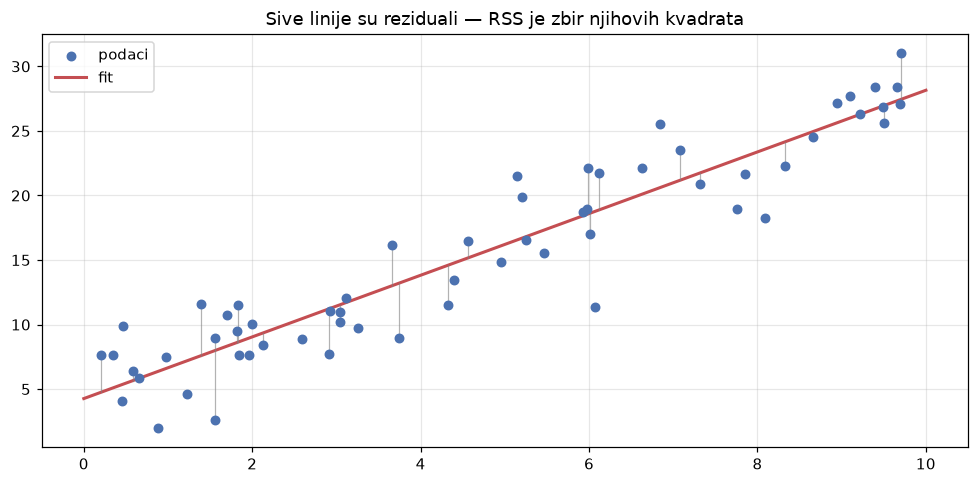

In [2]:
# sinteticki podaci sa poznatom pravom vezom
n = 60
Xs = rng.uniform(0, 10, n)
prava_b0, prava_b1 = 4.0, 2.5
ys = prava_b0 + prava_b1 * Xs + rng.normal(0, 3, n)

lin = LinearRegression().fit(Xs.reshape(-1, 1), ys)
b0, b1 = lin.intercept_, lin.coef_[0]
pred = lin.predict(Xs.reshape(-1, 1))
rss = np.sum((ys - pred) ** 2)

print(f"Prava veza    : y = {prava_b0:.2f} + {prava_b1:.2f}*x")
print(f"Procenjeno    : y = {b0:.2f} + {b1:.2f}*x")
print(f"RSS           : {rss:.1f}")

fig, ax = plt.subplots()
ax.scatter(Xs, ys, s=30, color="#4C72B0", label="podaci", zorder=3)
xx = np.linspace(0, 10, 100)
ax.plot(xx, lin.predict(xx.reshape(-1, 1)), color="#C44E52", lw=2, label="fit")
for xi, yi, pi in zip(Xs[:25], ys[:25], pred[:25]):
    ax.plot([xi, xi], [yi, pi], color="gray", lw=0.8, alpha=0.6)
ax.set_title("Sive linije su reziduali — RSS je zbir njihovih kvadrata")
ax.legend(); plt.tight_layout(); plt.show()

## Koliko je model dobro prilagođen

**RSE** (standardna greška reziduala) — veća vrednost znači lošije prilagođavanje.

**$R^2$** (koeficijent determinacije) — koliki deo varijabilnosti u $Y$ je objašnjen:

$$R^2 = 1 - \frac{RSS}{TSS}, \qquad TSS = \sum (y_i - \bar y)^2$$

| $R^2$ | značenje |
|---|---|
| 1 | savršeno prilagođavanje |
| 0 | model ne objašnjava ništa više od proste srednje vrednosti |
| < 0 | model je **lošiji** od predviđanja proseka |

**Koja vrednost je „dobra" zavisi od oblasti.** U fizici se očekuje $R^2$ blizu 1. U
biologiji i društvenim naukama $R^2 \approx 0.4$ može biti dobar rezultat.

In [3]:
tss = np.sum((ys - ys.mean()) ** 2)
r2_rucno = 1 - rss / tss
rse = np.sqrt(rss / (n - 2))

print(f"RSS = {rss:.1f}")
print(f"TSS = {tss:.1f}")
print(f"R^2 (rucno)   = {r2_rucno:.4f}")
print(f"R^2 (sklearn) = {r2_score(ys, pred):.4f}")
print(f"RSE           = {rse:.3f}")

# demonstracija granicnih slucajeva
prosek = np.full_like(ys, ys.mean())
lose = ys.mean() + 5 * (Xs - Xs.mean())      # namerno pogresan nagib
print(f"\nR^2 za predikciju proseka : {r2_score(ys, prosek):.4f}   (definiciono 0)")
print(f"R^2 za namerno los model  : {r2_score(ys, lose):.4f}   (negativan!)")

RSS = 418.3
TSS = 3558.1
R^2 (rucno)   = 0.8824
R^2 (sklearn) = 0.8824
RSE           = 2.686

R^2 za predikciju proseka : 0.0000   (definiciono 0)
R^2 za namerno los model  : -0.1726   (negativan!)


## Višestruka linearna regresija

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p + \varepsilon$$

**Tumačenje koeficijenta $\beta_j$:** prosečan uticaj povećanja $X_j$ za jednu jedinicu na
$Y$, **dok su sve ostale promenljive fiksirane**.

Zatvoreno (analitičko) rešenje:

$$\hat{\boldsymbol\beta} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{Y}$$

> **Zašto ne raditi prostu regresiju posebno za svaku promenljivu?** Zato što se time
> zanemaruje **međusobni uticaj** promenljivih. Koeficijent iz proste regresije može biti
> zavaravajući ako je promenljiva korelisana sa nekom drugom.

In [4]:
# TV, radio i novine -> prodaja; novine su korelisane sa radiom ali same ne uticu
m = 200
tv = rng.uniform(0, 300, m)
radio = rng.uniform(0, 50, m)
novine = 0.6 * radio + rng.normal(0, 8, m)          # korelisano sa radiom!
prodaja = 3 + 0.045 * tv + 0.19 * radio + rng.normal(0, 1.5, m)
df = pd.DataFrame({"TV": tv, "radio": radio, "novine": novine, "prodaja": prodaja})

print("PROSTE regresije (svaka promenljiva sama):")
for kol in ["TV", "radio", "novine"]:
    k = LinearRegression().fit(df[[kol]], df.prodaja).coef_[0]
    print(f"   {kol:<8} koeficijent = {k:+.4f}")

vis = LinearRegression().fit(df[["TV", "radio", "novine"]], df.prodaja)
print("\nVISESTRUKA regresija (sve zajedno):")
for kol, k in zip(["TV", "radio", "novine"], vis.coef_):
    print(f"   {kol:<8} koeficijent = {k:+.4f}")
print(f"\nKorelacija novine-radio: {df.novine.corr(df.radio):.3f}")
print("-> U prostoj regresiji 'novine' izgledaju znacajno, u visestrukoj koeficijent pada")
print("   ka nuli. Njihov 'efekat' je bio indirektan, preko radija.")

PROSTE regresije (svaka promenljiva sama):
   TV       koeficijent = +0.0399
   radio    koeficijent = +0.1593
   novine   koeficijent = +0.1474

VISESTRUKA regresija (sve zajedno):
   TV       koeficijent = +0.0431
   radio    koeficijent = +0.1683
   novine   koeficijent = +0.0215

Korelacija novine-radio: 0.790
-> U prostoj regresiji 'novine' izgledaju znacajno, u visestrukoj koeficijent pada
   ka nuli. Njihov 'efekat' je bio indirektan, preko radija.


## Kvalitativni (kategorijalni) ulazi

Kategorijalna promenljiva se uvodi preko **dummy (indikatorskih)** promenljivih.

Za promenljivu sa $K$ kategorija koristi se **$K-1$** dummy promenljivih. Jedna kategorija
se bira kao **bazna (referentna)** i predstavljena je sa svim nulama.

In [5]:
boje = pd.Series(rng.choice(["plava", "zelena", "braon"], 12))
dummy = pd.get_dummies(boje, prefix="oci", drop_first=True).astype(int)
print("Kategorije:", sorted(boje.unique()))
print(f"Broj dummy promenljivih: {dummy.shape[1]}  (K-1 = 3-1 = 2)")
print("Bazna kategorija je ona koje NEMA medju kolonama — nju predstavljaju sve nule.\n")
display(pd.concat([boje.rename("boja"), dummy], axis=1).head(6))

Kategorije: ['braon', 'plava', 'zelena']
Broj dummy promenljivih: 2  (K-1 = 3-1 = 2)
Bazna kategorija je ona koje NEMA medju kolonama — nju predstavljaju sve nule.



,boja,oci_plava,oci_zelena
0,braon,0,0
1,plava,1,0
2,zelena,0,1
3,braon,0,0
4,plava,1,0
5,braon,0,0


## Potencijalni problemi linearne regresije

1. **Nelinearnost** odnosa između odgovora i prediktora
2. **Ne-aditivnost** prediktora — interakcije
3. **Nekonstantna varijansa** grešaka (heteroskedastičnost)
4. **Outlieri** — neuobičajene vrednosti $Y$
5. **Tačke sa velikim uticajem** (high-leverage) — neuobičajene vrednosti $X$
6. **Korelisanost grešaka**
7. **Kolinearnost** — prediktori su međusobno snažno korelisani

### Nelinearnost → polinomska regresija

$$Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \varepsilon$$

Iako sadrži kvadratni član, model je i dalje **linearan u parametrima**, pa se fituje
istim metodom najmanjih kvadrata.

Dijagnostika: **grafik reziduala**. Ako se u njemu vidi obrazac, pretpostavka linearnosti
je upitna.

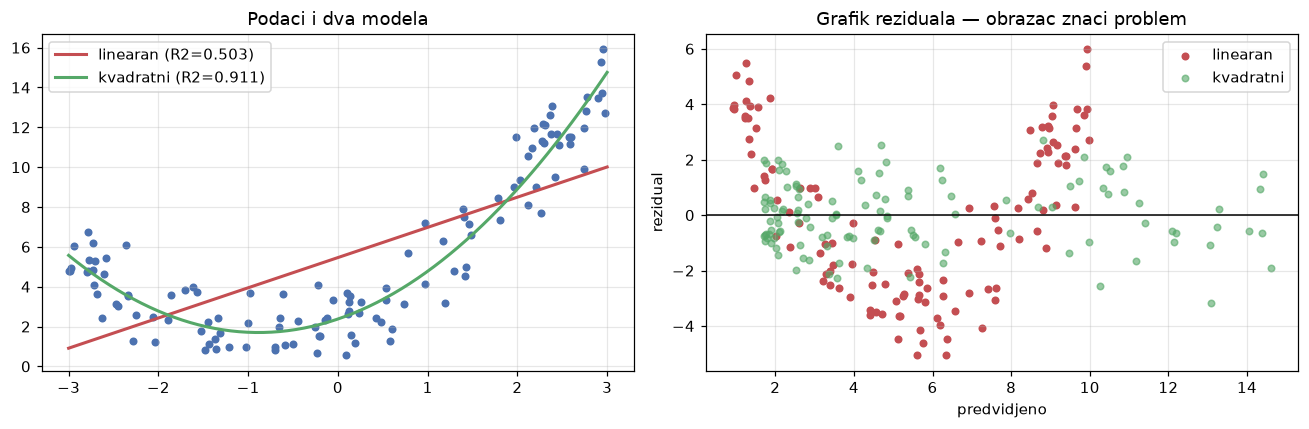

In [6]:
Xn = rng.uniform(-3, 3, 120)
yn = 2 + 1.5 * Xn + 0.9 * Xn ** 2 + rng.normal(0, 1.2, 120)
Xn2 = Xn.reshape(-1, 1)

lin_m = LinearRegression().fit(Xn2, yn)
pol_m = make_pipeline(PolynomialFeatures(2), LinearRegression()).fit(Xn2, yn)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
xx = np.linspace(-3, 3, 200).reshape(-1, 1)
ax[0].scatter(Xn, yn, s=18, color="#4C72B0")
ax[0].plot(xx, lin_m.predict(xx), color="#C44E52", lw=2, label=f"linearan (R2={r2_score(yn, lin_m.predict(Xn2)):.3f})")
ax[0].plot(xx, pol_m.predict(xx), color="#55A868", lw=2, label=f"kvadratni (R2={r2_score(yn, pol_m.predict(Xn2)):.3f})")
ax[0].set_title("Podaci i dva modela"); ax[0].legend()

ax[1].scatter(lin_m.predict(Xn2), yn - lin_m.predict(Xn2), s=18, color="#C44E52", label="linearan")
ax[1].scatter(pol_m.predict(Xn2), yn - pol_m.predict(Xn2), s=18, color="#55A868", alpha=0.6, label="kvadratni")
ax[1].axhline(0, color="k", lw=1)
ax[1].set_xlabel("predvidjeno"); ax[1].set_ylabel("rezidual")
ax[1].set_title("Grafik reziduala — obrazac znaci problem"); ax[1].legend()
plt.tight_layout(); plt.show()

### Ne-aditivnost → interakcioni član

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_1 X_2 + \varepsilon$$

Član $X_1 X_2$ omogućava da **efekat jednog prediktora zavisi od vrednosti drugog**.
Primer: popust ima različit efekat u sezoni i van sezone.

In [7]:
popust = rng.uniform(0, 30, 300)
sezona = rng.choice([0, 1], 300)
# efekat popusta je JACI u sezoni -> interakcija
prod = 10 + 0.5 * popust + 4 * sezona + 0.6 * popust * sezona + rng.normal(0, 2, 300)
d2 = pd.DataFrame({"popust": popust, "sezona": sezona, "prodaja": prod})

bez = LinearRegression().fit(d2[["popust", "sezona"]], d2.prodaja)
d2["inter"] = d2.popust * d2.sezona
sa = LinearRegression().fit(d2[["popust", "sezona", "inter"]], d2.prodaja)

print(f"BEZ interakcije: R2 = {r2_score(d2.prodaja, bez.predict(d2[['popust','sezona']])):.4f}")
print(f"SA interakcijom: R2 = {r2_score(d2.prodaja, sa.predict(d2[['popust','sezona','inter']])):.4f}")
print(f"\nKoeficijent interakcije: {sa.coef_[2]:+.4f}")
print("-> pozitivan: popust radi JACE u sezoni nego van nje")

BEZ interakcije: R2 = 0.9044
SA interakcijom: R2 = 0.9639

Koeficijent interakcije: +0.5925
-> pozitivan: popust radi JACE u sezoni nego van nje


### Nekonstantna varijansa → log-transformacija

Prepoznaje se po **levkastom obliku** na grafiku reziduala. Rešenje je transformacija
ciljne promenljive konkavnom funkcijom, najčešće **logaritmom**.

Interpretacija se menja: bez loga koeficijent znači „porast za toliko jedinica", sa logom
znači „porast za toliko **procenata**".

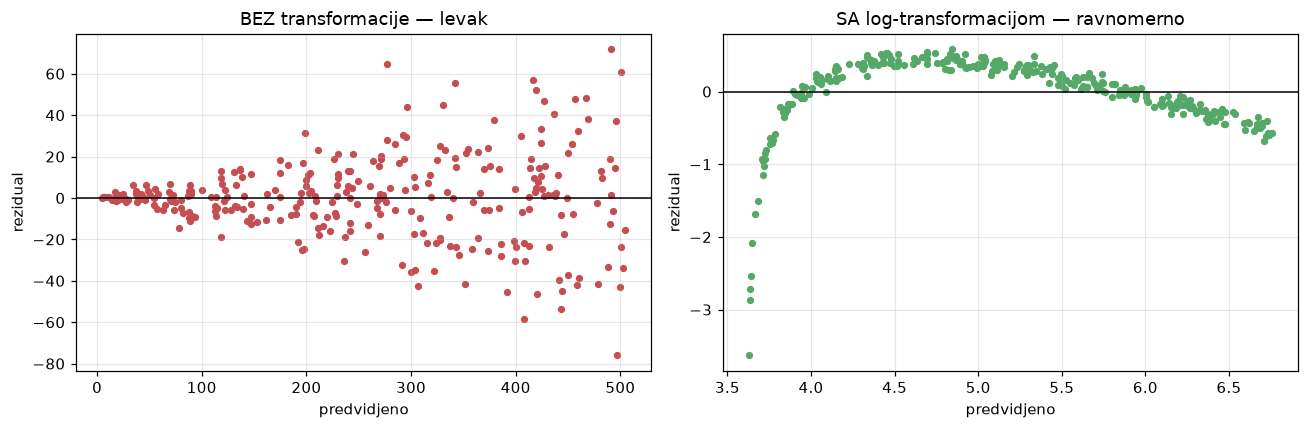

In [8]:
Xh = rng.uniform(1, 100, 300)
yh = 5 * Xh + rng.normal(0, 0.35 * Xh, 300)          # greska raste sa X -> levak
Xh2 = Xh.reshape(-1, 1)

m1 = LinearRegression().fit(Xh2, yh)
m2 = LinearRegression().fit(Xh2, np.log(yh - yh.min() + 1))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(m1.predict(Xh2), yh - m1.predict(Xh2), s=14, color="#C44E52")
ax[0].axhline(0, color="k", lw=1); ax[0].set_title("BEZ transformacije — levak")
ax[0].set_xlabel("predvidjeno"); ax[0].set_ylabel("rezidual")

yl = np.log(yh - yh.min() + 1)
ax[1].scatter(m2.predict(Xh2), yl - m2.predict(Xh2), s=14, color="#55A868")
ax[1].axhline(0, color="k", lw=1); ax[1].set_title("SA log-transformacijom — ravnomerno")
ax[1].set_xlabel("predvidjeno"); ax[1].set_ylabel("rezidual")
plt.tight_layout(); plt.show()

### Regularizacija — Ridge i Lasso

Varijacije linearne regresije koje dodaju kazneni član i time smanjuju overfitting:

| metoda | kazna | efekat |
|---|---|---|
| **Ridge** (L2) | $\lambda \sum w_j^2$ | smanjuje sve težine ka nuli |
| **Lasso** (L1) | $\lambda \sum \lvert w_j \rvert$ | može težine **ugasiti** na tačno 0 |

Lasso zato služi i kao **izbor obeležja**.

In [9]:
from sklearn.datasets import make_regression
Xr, yr = make_regression(n_samples=100, n_features=25, n_informative=5,
                         noise=12, random_state=RS)
Xr_s = StandardScaler().fit_transform(Xr)

rezultati = []
for ime, m in [("LinearRegression", LinearRegression()),
               ("Ridge (alpha=10)", Ridge(alpha=10)),
               ("Lasso (alpha=1)", Lasso(alpha=1.0))]:
    m.fit(Xr_s, yr)
    rezultati.append({"model": ime, "R2": round(r2_score(yr, m.predict(Xr_s)), 4),
                      "tezina ~0": int(np.sum(np.abs(m.coef_) < 1e-6)),
                      "max |w|": round(np.abs(m.coef_).max(), 1)})
pd.DataFrame(rezultati)

,model,R2,tezina ~0,max |w|
0,LinearRegression,0.9929,0,82.6
1,Ridge (alpha=10),0.9822,0,73.8
2,Lasso (alpha=1),0.9916,12,81.5


---
## Logistička regresija

Koristi se za **klasifikaciju**. Modeluje verovatnoću:

$$P(Y = 1 \mid X) = \sigma(\beta_0 + \beta_1 X), \qquad \sigma(z) = \frac{1}{1 + e^{-z}}$$

### Zašto ne linearna regresija za verovatnoću?

- verovatnoća mora biti u $[0, 1]$, a linearna funkcija daje i vrednosti $< 0$ i $> 1$
- linearna veza nije realistična za klasifikaciju

### Uticaj parametara na sigmoidnu krivu

| parametar | efekat |
|---|---|
| $\beta_0$ | **horizontalni pomak** krive levo/desno; početna sklonost ka klasi 1 |
| $\beta_1$ | **strmina** krive; veće $\beta_1$ = oštrija odluka |

Koeficijenti se procenjuju metodom **maksimalne verodostojnosti** (maximum likelihood) —
za razliku od linearne regresije, **nema zatvorenog rešenja**.

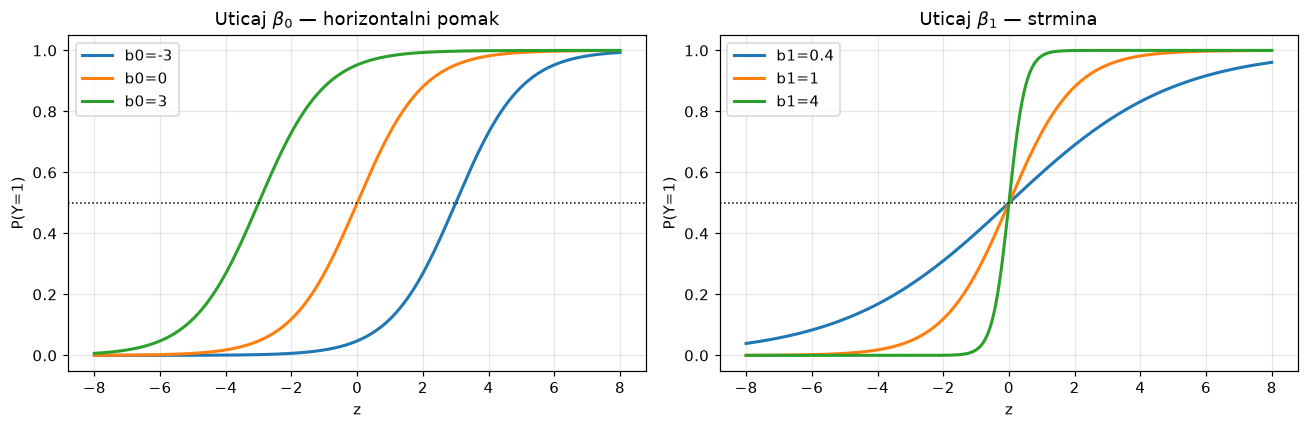

In [10]:
z = np.linspace(-8, 8, 300)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for b0 in (-3, 0, 3):
    ax[0].plot(z, 1 / (1 + np.exp(-(b0 + 1 * z))), lw=2, label=f"b0={b0}")
ax[0].set_title("Uticaj $\\beta_0$ — horizontalni pomak"); ax[0].legend()
ax[0].axhline(0.5, color="k", ls=":", lw=1)

for b1 in (0.4, 1, 4):
    ax[1].plot(z, 1 / (1 + np.exp(-(0 + b1 * z))), lw=2, label=f"b1={b1}")
ax[1].set_title("Uticaj $\\beta_1$ — strmina"); ax[1].legend()
ax[1].axhline(0.5, color="k", ls=":", lw=1)

for a in ax: a.set_xlabel("z"); a.set_ylabel("P(Y=1)")
plt.tight_layout(); plt.show()

In [11]:
from sklearn.datasets import load_breast_cancer
bc = load_breast_cancer(as_frame=True)
Xb, yb = bc.data, bc.target
Xtr, Xte, ytr, yte = train_test_split(Xb, yb, test_size=0.3, random_state=RS, stratify=yb)

log = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(Xtr, ytr)
verov = log.predict_proba(Xte)[:, 1]

print(f"Tacnost: {log.score(Xte, yte):.4f}")
print(f"\nModel vraca VEROVATNOCE, ne klase:")
print(f"   prvih 6 verovatnoca: {verov[:6].round(3)}")
print(f"   klase uz prag 0.5  : {(verov[:6] >= 0.5).astype(int)}")

Tacnost: 0.9883

Model vraca VEROVATNOCE, ne klase:
   prvih 6 verovatnoca: [0.032 0.95  0.984 0.001 0.285 0.001]
   klase uz prag 0.5  : [0 1 1 0 0 0]


### Prag odlučivanja (threshold)

Logistička regresija daje **verovatnoću**. Da bi se donela odluka o klasi, uvodi se **prag**,
najčešće 0.5:

- ako je $p \geq 0.5$ → klasa 1
- ako je $p < 0.5$ → klasa 0

Prag se može pomerati — time se model čini konzervativnijim ili liberalnijim.

In [12]:
redovi = []
for prag in (0.1, 0.3, 0.5, 0.7, 0.9):
    pred = (verov >= prag).astype(int)
    redovi.append({
        "prag": prag,
        "tacnost": round(accuracy_score(yte, pred), 3),
        "preciznost": round(precision_score(yte, pred, zero_division=0), 3),
        "odziv": round(recall_score(yte, pred), 3),
    })
print("Nizi prag = model je 'liberalniji', hvata vise pozitivnih ali gresi vise:")
pd.DataFrame(redovi)

Nizi prag = model je 'liberalniji', hvata vise pozitivnih ali gresi vise:


,prag,tacnost,preciznost,odziv
0,0.1,0.947,0.922,1.000
1,0.3,0.982,0.973,1.000
2,0.5,0.988,0.991,0.991
3,0.7,0.959,0.990,0.944
4,0.9,0.906,1.000,0.850


## Ocena klasifikatora — matrica konfuzije i metrike

|  | predviđeno 0 | predviđeno 1 |
|---|---|---|
| **stvarno 0** | TN | FP |
| **stvarno 1** | FN | TP |

$$\text{Tačnost} = \frac{TP+TN}{n} \qquad
\text{Preciznost} = \frac{TP}{TP+FP} \qquad
\text{Odziv} = \frac{TP}{TP+FN}$$

$$\text{Specifičnost} = \frac{TN}{FP+TN} \qquad
FPR = \frac{FP}{FP+TN}$$

**ROC kriva** prikazuje kompromis između odziva (TPR) i stope lažno pozitivnih (FPR) pri
različitim pragovima. **AUC** je površina ispod nje i sažima performansu u jedan broj.

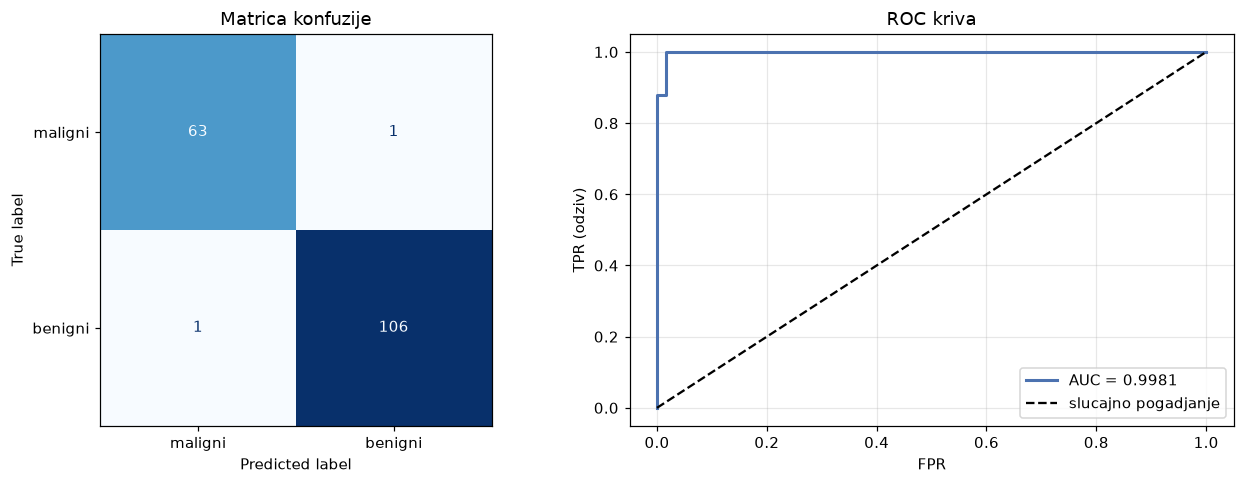

TN=63  FP=1  FN=1  TP=106
Tacnost      = (TP+TN)/n     = 0.9883
Preciznost   = TP/(TP+FP)    = 0.9907
Odziv        = TP/(TP+FN)    = 0.9907
Specificnost = TN/(FP+TN)    = 0.9844


In [13]:
pred = (verov >= 0.5).astype(int)
cm = confusion_matrix(yte, pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(cm, display_labels=["maligni", "benigni"]).plot(ax=ax[0], colorbar=False, cmap="Blues")
ax[0].set_title("Matrica konfuzije"); ax[0].grid(False)

fpr, tpr, _ = roc_curve(yte, verov)
ax[1].plot(fpr, tpr, lw=2, color="#4C72B0", label=f"AUC = {roc_auc_score(yte, verov):.4f}")
ax[1].plot([0, 1], [0, 1], "k--", label="slucajno pogadjanje")
ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR (odziv)"); ax[1].set_title("ROC kriva")
ax[1].legend()
plt.tight_layout(); plt.show()

print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"Tacnost      = (TP+TN)/n     = {(tp+tn)/cm.sum():.4f}")
print(f"Preciznost   = TP/(TP+FP)    = {tp/(tp+fp):.4f}")
print(f"Odziv        = TP/(TP+FN)    = {tp/(tp+fn):.4f}")
print(f"Specificnost = TN/(FP+TN)    = {tn/(fp+tn):.4f}")

## Sažetak

| | linearna regresija | logistička regresija |
|---|---|---|
| cilj | neprekidna vrednost | verovatnoća klase |
| procena parametara | metod najmanjih kvadrata (zatvoreno rešenje) | maksimalna verodostojnost (iterativno) |
| glavne metrike | RSE, $R^2$ | tačnost, preciznost, odziv, AUC |
| **prednost** | jednostavan, koeficijenti se lako tumače | log-odnosi linearni, nema hiperparametara |
| **nedostatak** | osetljiv na outliere, može biti presimplifikovan | ne modeluje složene granice odlučivanja |